<a href="https://colab.research.google.com/github/sanaullah-developer/tensorflow_practice/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import tensorflow as tf # deep learning modeling
import pandas as pd # reading and processing data
import seaborn as sns # visualizations
from tensorflow.keras.layers import Normalization,Dense
from tensorflow.keras.losses import MeanSquaredError,MeanAbsoluteError, Huber
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt

In [69]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# Step 2: Change the current working directory to where your notebook and 'train.csv' are located
import os

notebook_dir = '/content/drive/MyDrive/Colab Notebooks/cv practice/used_car/'
os.chdir(notebook_dir)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/MyDrive/Colab Notebooks/cv practice/used_car


In [71]:
# Step 3: Load the 'train.csv' file into a pandas DataFrame

df = pd.read_csv('train.csv')
#sometimes our delimeter may be ';' or something else other than comman then we can use
# pd.read_csv('train.csv',';') by specifying the delimeter
# Display the first 5 rows to confirm it loaded correctly
display(df.head())

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


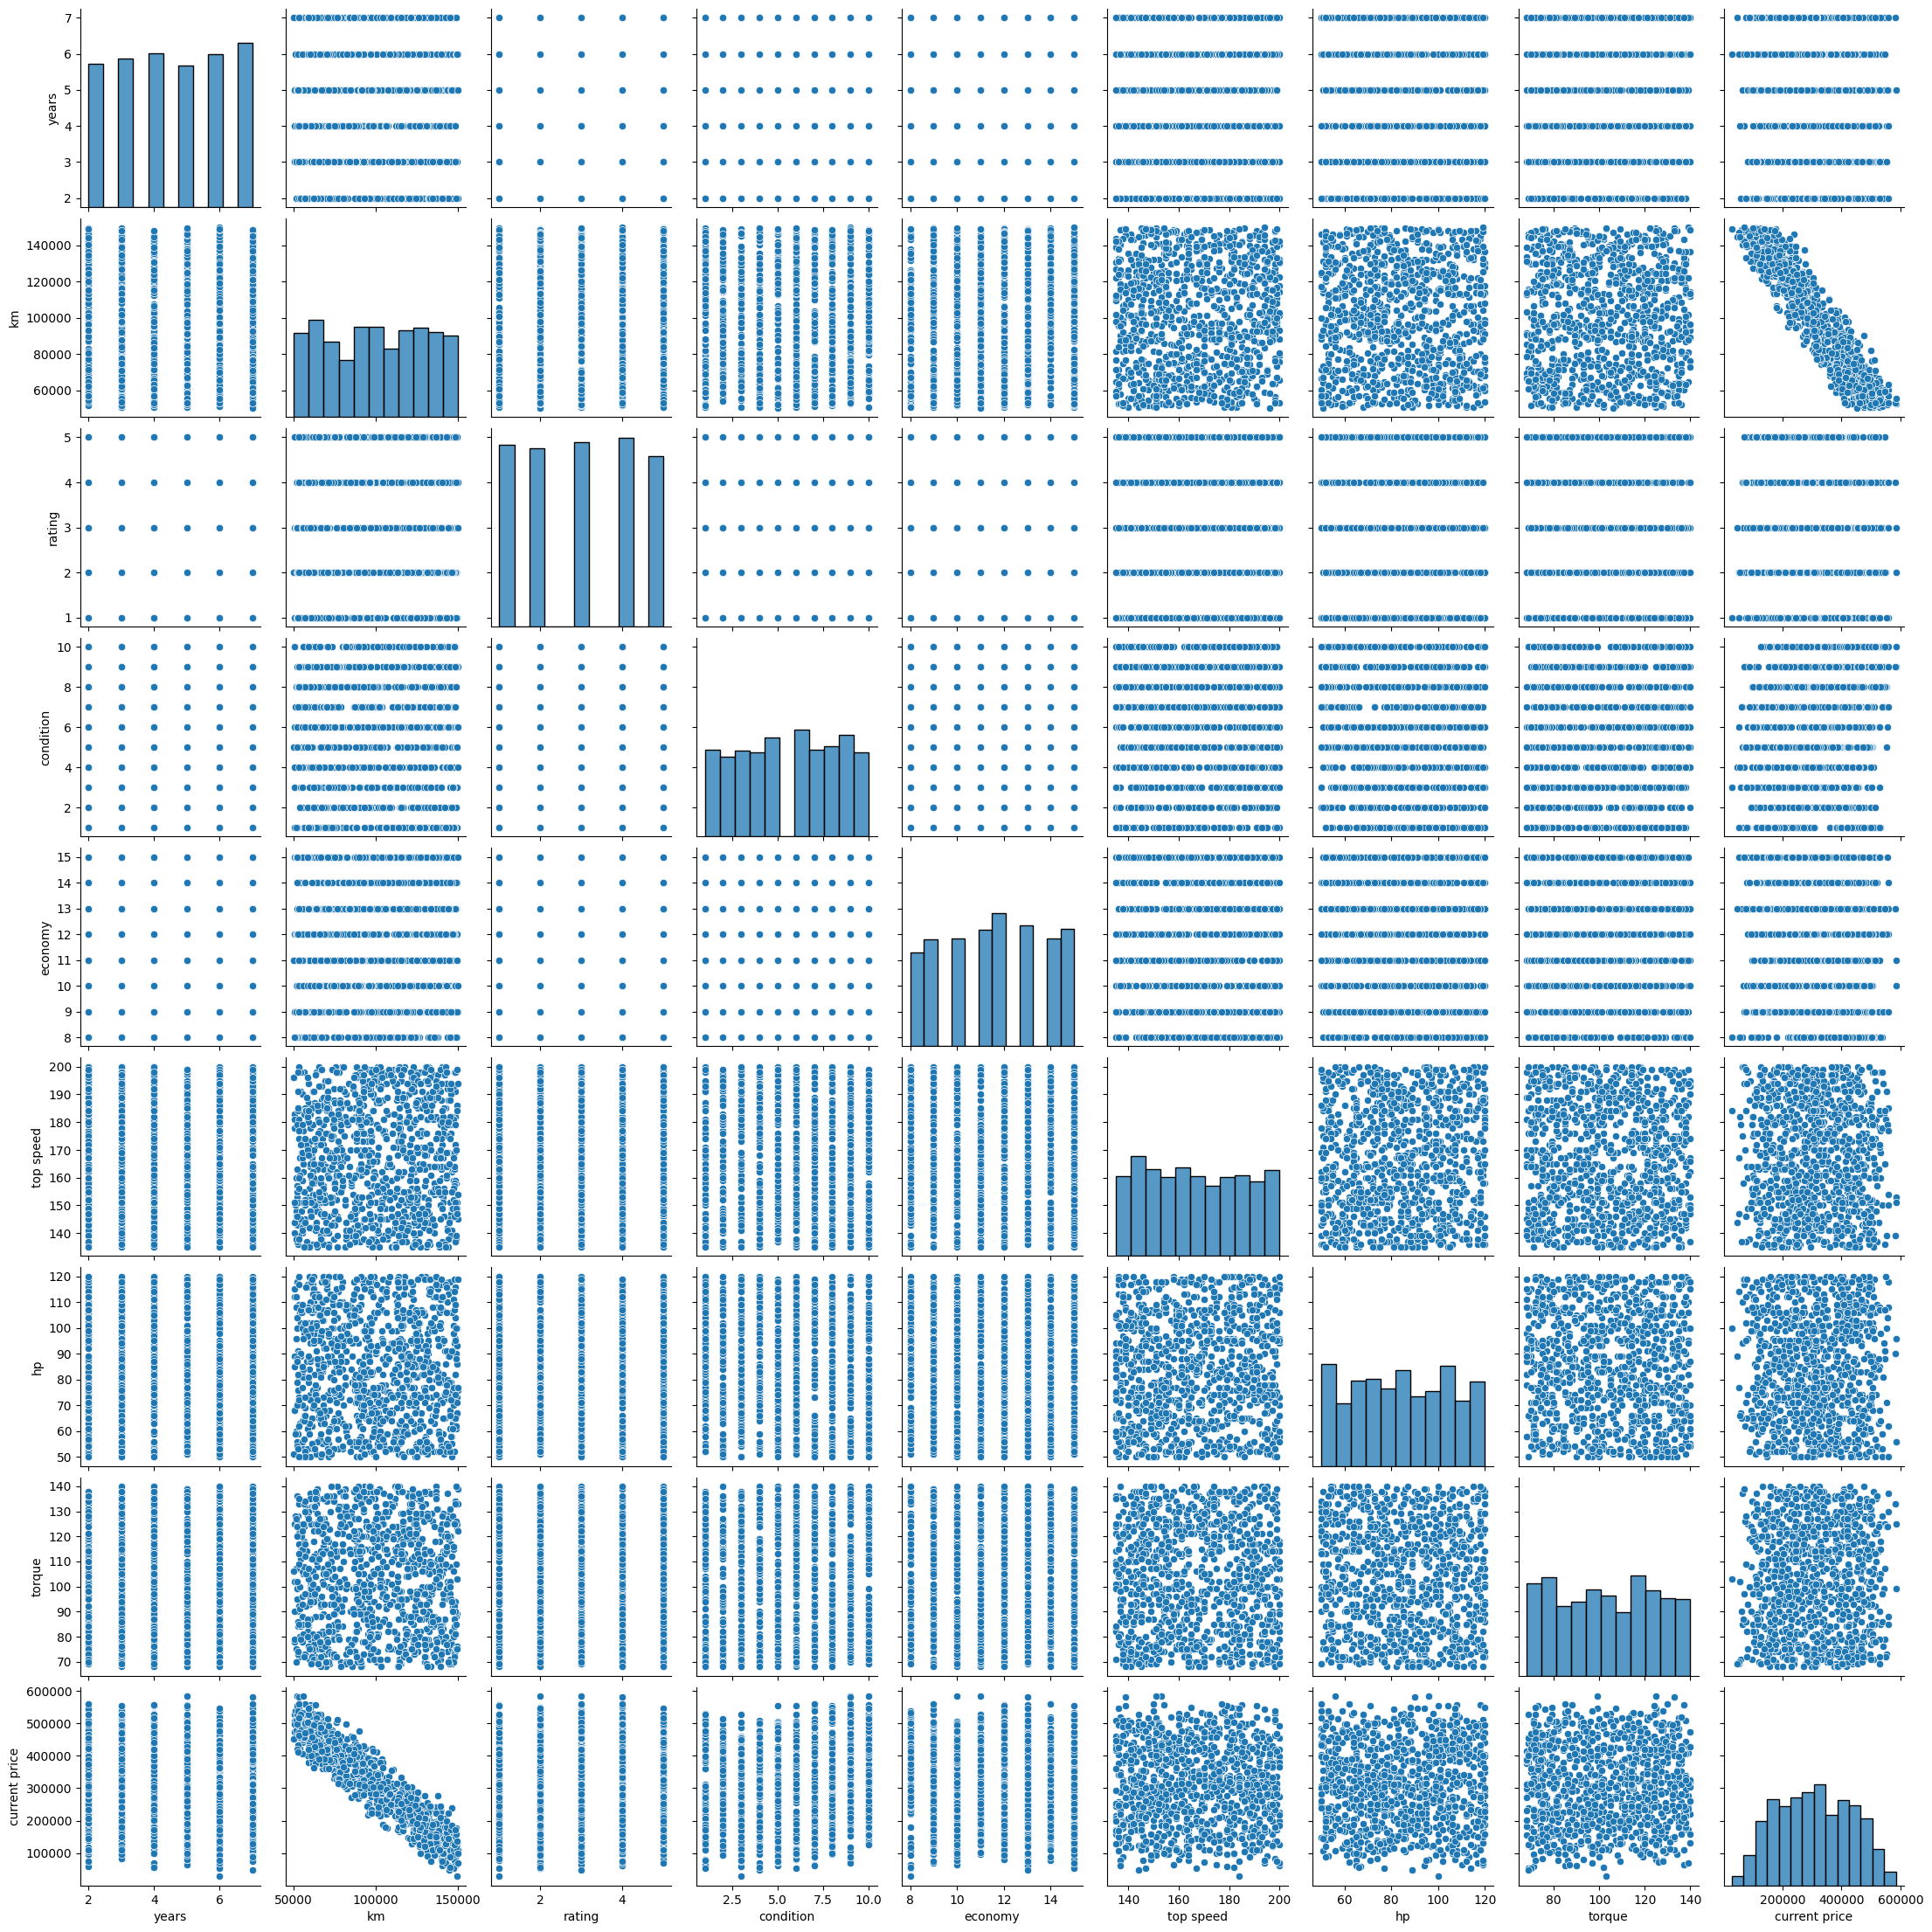

In [72]:
sns.pairplot(df.iloc[:, 3:])

In [73]:
# now we have to convert the data from dataframes into tensors
tensor_data=tf.constant(df)
tensor_data=tf.cast(tensor_data,tf.float32)
print(tensor_data)

tf.Tensor(
[[1.000000e+00 5.356510e+05 7.981860e+05 ... 7.300000e+01 1.230000e+02
  3.513180e+05]
 [2.000000e+00 5.919110e+05 8.610560e+05 ... 7.400000e+01 9.500000e+01
  2.850015e+05]
 [3.000000e+00 6.869900e+05 7.707620e+05 ... 5.300000e+01 9.700000e+01
  2.153860e+05]
 ...
 [9.980000e+02 6.463440e+05 8.427330e+05 ... 1.130000e+02 8.900000e+01
  4.058710e+05]
 [9.990000e+02 5.355590e+05 7.324390e+05 ... 1.120000e+02 1.280000e+02
  7.439800e+04]
 [1.000000e+03 5.901050e+05 7.797430e+05 ... 9.900000e+01 9.600000e+01
  4.149385e+05]], shape=(1000, 12), dtype=float32)


In [74]:
#to remove any biasness from model we have to shuffle the data
tensor_data=tf.random.shuffle(tensor_data)

In [75]:
# separating the input and output features
X=tensor_data[:,3:-1]
print(X[0:5])

tf.Tensor(
[[5.00000e+00 8.25800e+04 4.00000e+00 3.00000e+00 1.20000e+01 1.87000e+02
  9.80000e+01 1.00000e+02]
 [3.00000e+00 8.84290e+04 5.00000e+00 7.00000e+00 1.40000e+01 1.74000e+02
  5.40000e+01 8.50000e+01]
 [6.00000e+00 1.42975e+05 4.00000e+00 4.00000e+00 1.50000e+01 1.64000e+02
  5.50000e+01 1.14000e+02]
 [3.00000e+00 7.08880e+04 3.00000e+00 5.00000e+00 1.50000e+01 1.89000e+02
  8.90000e+01 1.09000e+02]
 [6.00000e+00 1.27668e+05 2.00000e+00 6.00000e+00 1.40000e+01 1.88000e+02
  1.07000e+02 1.32000e+02]], shape=(5, 8), dtype=float32)


In [76]:
y=tensor_data[:,-1]
y=tf.expand_dims(y,axis=-1)
print(y[:5])

tf.Tensor(
[[299609. ]
 [343595. ]
 [150234.5]
 [423584. ]
 [149141.5]], shape=(5, 1), dtype=float32)


In [77]:
X.shape

TensorShape([1000, 8])

In [78]:
TRAIN_RATIO=0.8
VAL_RATIO=0.1
TEST_RATIO=0.1
DATASET_SIZE=len(X)

In [79]:
X_train=X[:int(DATASET_SIZE*TRAIN_RATIO)]
y_train=y[:int(DATASET_SIZE*TRAIN_RATIO)]
print(X_train.shape)
print(y_train.shape)

(800, 8)
(800, 1)


In [80]:
X_val=X[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]
y_val=y[int(DATASET_SIZE*TRAIN_RATIO):int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO))]
print(X_val.shape)
print(y_val.shape)

(100, 8)
(100, 1)


In [81]:
X_test=X[int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO)):]
y_test=y[int(DATASET_SIZE*(TRAIN_RATIO+VAL_RATIO)):]
print(X_test.shape)
print(y_test.shape)

(100, 8)
(100, 1)


In [82]:
BUFFER_SIZE = 16
BATCH_SIZE = 64

In [83]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train,y_train))
train_dataset = train_dataset.shuffle(buffer_size = BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [84]:
val_dataset = tf.data.Dataset.from_tensor_slices((X_val,y_val))
val_dataset = val_dataset.shuffle(buffer_size = BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [85]:
test_dataset = tf.data.Dataset.from_tensor_slices((X_test,y_test))
test_dataset = test_dataset.shuffle(buffer_size = BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [86]:
for i,j in train_dataset:
  print(i.shape,j.shape)
  break

(64, 8) (64, 1)


In [87]:
normalizer= Normalization()
normalizer.adapt(X_train)
normalizer(X)

<tf.Tensor: shape=(1000, 8), dtype=float32, numpy=
array([[ 0.25171265, -0.59001577,  0.7117659 , ...,  1.039335  ,
         0.67931753, -0.1540686 ],
       [-0.91565007, -0.38964042,  1.4208726 , ...,  0.36549413,
        -1.4641011 , -0.8659767 ],
       [ 0.835394  ,  1.4789995 ,  0.7117659 , ..., -0.15284504,
        -1.415387  ,  0.51037896],
       ...,
       [-1.4993315 ,  0.76403385,  1.4208726 , ..., -1.0340216 ,
         1.4587425 , -1.1032795 ],
       [-0.33196872, -1.3320795 ,  0.7117659 , ..., -0.3601807 ,
         1.6535988 , -0.20152915],
       [-0.33196872,  0.5657825 ,  0.00265921, ...,  0.20999238,
         1.06903   ,  0.7002211 ]], dtype=float32)>

In [88]:
model = tf.keras.Sequential([
    normalizer,
    Dense(128),
    Dense(128),
    Dense(128),
    Dense(1),
],name="first-model")
model.summary()

Model: "first-model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (800, 8)               │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

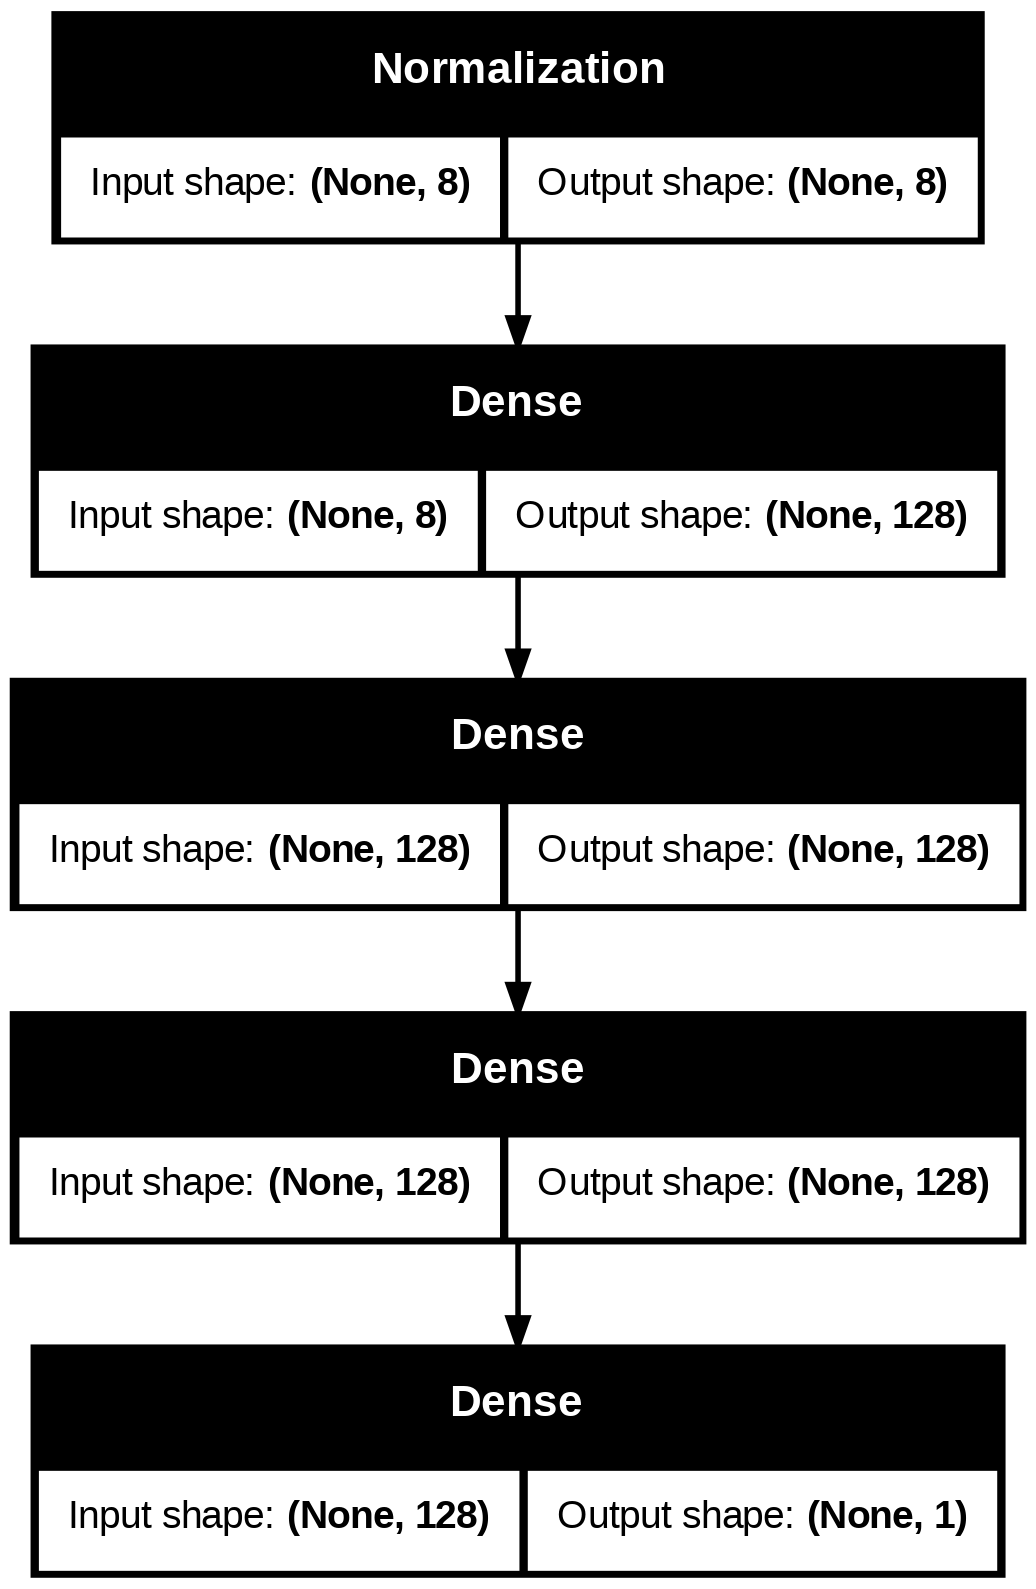

In [90]:
model.build(input_shape=(None, X_train.shape[1]))
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True)

In [92]:
model.compile(optimizer = Adam(learning_rate = 0.1),
              loss = MeanAbsoluteError(),
              metrics = [RootMeanSquaredError()]) # Now RootMeanSquaredError is correctly wrapped in a list

In [93]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,epochs = 100, verbose = 1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 274606.2812 - root_mean_squared_error: 304868.2812 - val_loss: 90079.5234 - val_root_mean_squared_error: 104482.5000
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 100061.4766 - root_mean_squared_error: 121612.6797 - val_loss: 70785.2812 - val_root_mean_squared_error: 89618.0391
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63040.6992 - root_mean_squared_error: 77109.0312 - val_loss: 41960.7109 - val_root_mean_squared_error: 53570.9102
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45308.0703 - root_mean_squared_error: 55906.5273 - val_loss: 41557.9062 - val_root_mean_squared_error: 52172.5781
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44724.0078 - root_mean_squared_error: 55566.2188 - val_loss: 32182.2695 - val_root_mean_squared_error: 39493.4453
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37992.9102 - root_mean_squared_error: 46339.5195 - val_loss: 30945.125

In [94]:
history.history

{'loss': [226108.6875,
  95035.546875,
  57056.94921875,
  46329.875,
  43408.78515625,
  38818.3515625,
  41612.1953125,
  42158.44140625,
  40123.734375,
  38774.7734375,
  39349.3515625,
  38074.89453125,
  42485.44140625,
  39547.265625,
  38343.09375,
  41029.5234375,
  40298.578125,
  41113.87890625,
  40022.70703125,
  38771.46484375,
  40161.7109375,
  38136.6484375,
  39194.1328125,
  38454.91015625,
  38469.890625,
  38081.7421875,
  37748.33203125,
  41727.234375,
  44105.4453125,
  39335.9140625,
  38591.359375,
  41096.76171875,
  38417.1484375,
  40725.98828125,
  38122.23046875,
  38714.94921875,
  41592.48828125,
  39395.12109375,
  39144.97265625,
  38293.99609375,
  39019.5859375,
  38272.56640625,
  38135.67578125,
  38635.73046875,
  39955.703125,
  38472.31640625,
  38911.78515625,
  38156.9921875,
  37816.05078125,
  39751.99609375,
  40375.24609375,
  37360.2265625,
  40467.109375,
  39978.1796875,
  36920.2265625,
  40099.9453125,
  41691.0625,
  38298.640625,
 

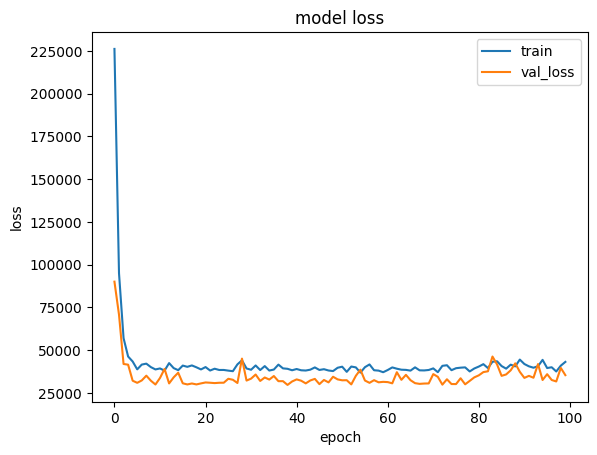

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'])
plt.show()

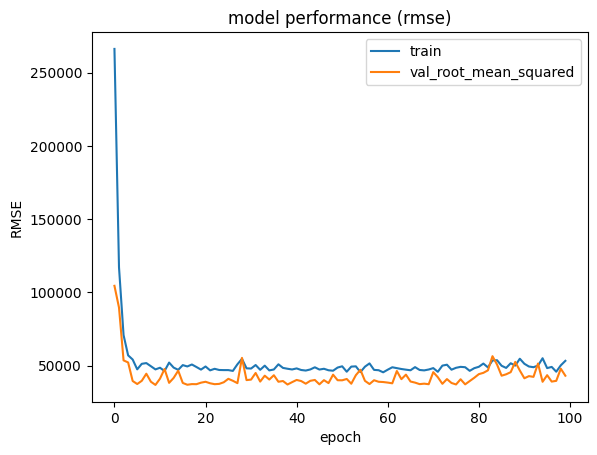

In [96]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model performance (rmse)')
plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.legend(['train','val_root_mean_squared'])
plt.show()

In [97]:
model.evaluate(val_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 35265.4180 - root_mean_squared_error: 43100.4414


[35431.0859375, 43100.51953125]

In [98]:
model.evaluate(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 38445.2500 - root_mean_squared_error: 45150.1680


[37366.578125, 44218.28515625]

In [100]:
y_output = model.predict(tf.expand_dims(X_test[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


In [101]:
print(y_output)

[[291549.66]]


In [102]:
y_pred = model(X_test)[:,0].numpy()
print(y_pred)

[291549.7   547802.7   443242.84  247074.44  141658.73  165860.34
 480998.44  453107.8   252324.8   423292.34  253922.14  507507.97
 463136.38  265602.72  251872.73  535146.5   152843.1   406285.34
 411914.56  252172.52  193741.34  476392.56  221307.67  265306.3
 548394.94  251130.44  509347.88  237283.38  166181.6   223393.47
 354578.88  436119.3   164009.06  192656.31  240026.38  257703.03
 512871.7   408417.06  402188.66  341337.5   452402.    425829.53
 394331.44  416516.56  480584.34  289313.8   310704.94  356024.25
 334175.97  324139.    538651.7   139129.92  492729.2   407583.44
 270259.34  156857.12  254507.78  242237.03  113430.38  137570.47
 524039.6   346279.12  157192.61  243018.69  411692.38  191216.98
 243310.9   145188.    138845.02  494816.72  241986.44  506171.25
 175125.34  214528.    125489.07  285312.6   485038.75  324766.8
 506044.5   213778.88  120232.414 195707.52  236338.47  318572.4
 392134.3   192079.42  537846.6   129340.055 152986.36  535350.9
 430140.7   42

In [103]:
y_true = y_test[:,0].numpy()
print(y_true)

[216327.  582347.  410516.  265799.5  77277.   93190.5 429837.5 360737.5
 274357.5 467074.5 273707.  538075.5 413954.5 202883.5 272075.  515722.5
 100927.  395188.  401120.5 286937.5 195854.  432836.  268200.5 247277.5
 468543.  258268.5 483884.  273674.5 245854.5 245796.  400027.5 493806.5
  74398.  197377.5 175810.  275670.  456154.5 422439.5 333672.  378132.5
 368522.5 443423.  373529.  327454.5 438223.  313879.  291810.  328698.
 387321.5 335093.5 507799.  118348.5 424781.  379491.  301591.  120092.5
 306660.  267953.5 108921.5  76772.  512885.5 344339.5 223885.  239923.
 367734.5 213768.5 262576.   69231.5 171620.  440044.5 272816.5 451140.5
 206883.5 193067.   97280.5 310987.  408860.5 369149.  489368.  167998.
 173847.  159647.  208189.5 296565.5 389099.  169125.5 555336.5 132159.
 158250.5 479318.5 380928.5 448905.5 382241.  347784.5 420083.   70862.
 506854.  299655.  492951.  187050. ]


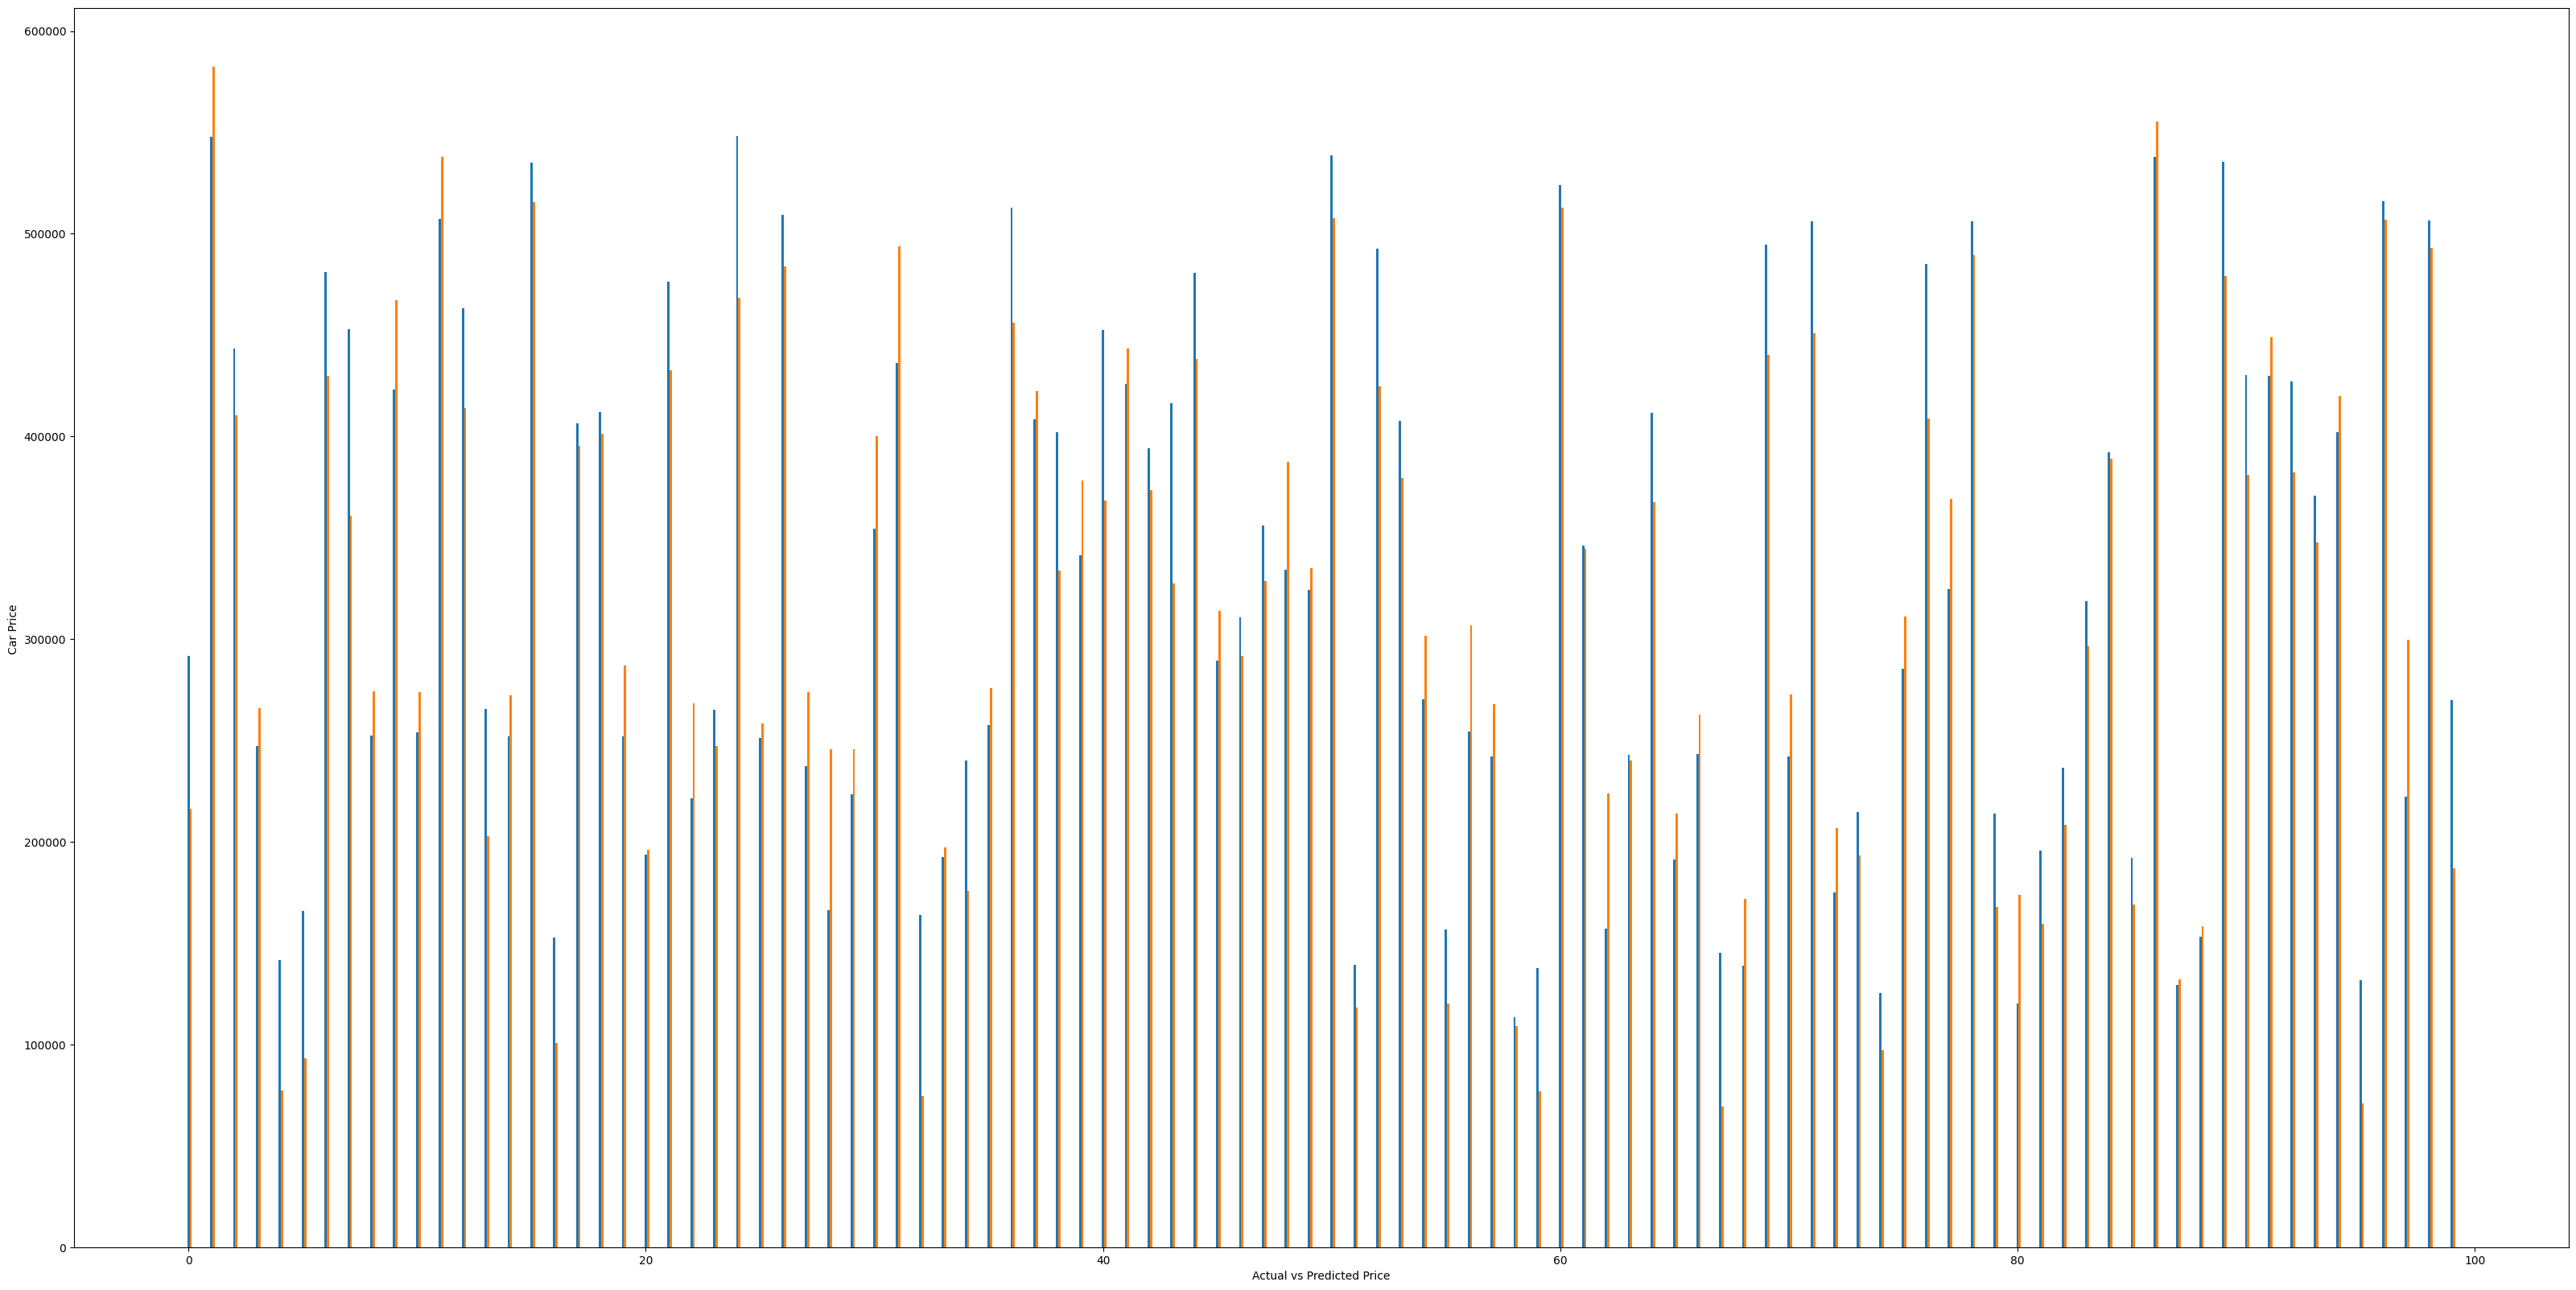

In [104]:
plt.figure(figsize = (40,20))

width = 0.1

plt.bar(tf.range(100).numpy(), y_pred, width, label='Model prediction')
plt.bar(tf.range(100).numpy()+width, y_true, width, label='Model prediction')

plt.xlabel("Actual vs Predicted Price")
plt.ylabel("Car Price ")

plt.show()